# Price-Based Stress Model (Exploratory)

This notebook uses system prices as a proxy for system stress,
defining high-price events as the top 10% of settlement periods.

The goal is to explore whether price-based signals can capture
constraint behaviour using wind generation and demand.

Key result:
Wind reduces the probability of high-price events due to its low marginal cost,
highlighting a disconnect between market signals and physical constraints.

In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import requests
import time
from datetime import date, timedelta
import os
from dotenv import load_dotenv

In [2]:
load_dotenv()
BASE = "https://data.elexon.co.uk/bmrs/api/v1"

def fetch_mid_day(settlement_date: date) -> pd.DataFrame:
    """
    MID = Market Index Data (price & volume per SP).
    Two providers per SP: APXMIDP and N2EXMIDP.
    We take the volume-weighted average across both = best SBP/SSP proxy.
    """
    params = {
        "from":   settlement_date.strftime("%Y-%m-%dT00:00Z"),
        "to":     settlement_date.strftime("%Y-%m-%dT23:59Z"),
        "format": "json",
    }
    r = requests.get(f"{BASE}/datasets/MID", params=params, timeout=30)

    if r.status_code != 200:
        print(f"  {settlement_date}: HTTP {r.status_code}")
        return pd.DataFrame()

    rows = r.json().get("data", [])
    return pd.DataFrame(rows)


# ── FETCH FULL YEAR ────────────────────────────────────────────────────
all_rows = []
current = date(2022, 1, 1)
end     = date(2022, 12, 31)

while current <= end:
    df_day = fetch_mid_day(current)
    if not df_day.empty:
        all_rows.append(df_day)
    if current.day == 1:
        print(f"  Fetching {current.strftime('%Y-%m')}...")
    current += timedelta(days=1)
    time.sleep(0.3)

df_raw = pd.concat(all_rows, ignore_index=True)
print(f"\nRaw shape: {df_raw.shape}")
print(f"Providers: {df_raw['dataProvider'].unique()}")

# ── VOLUME-WEIGHTED AVERAGE ACROSS PROVIDERS PER SP ───────────────────
# Each SP has 2 rows (APXMIDP + N2EXMIDP) — combine into one price
df_raw['settlementDate'] = pd.to_datetime(df_raw['settlementDate'])

df_sysp = (
    df_raw.groupby(['settlementDate', 'settlementPeriod'])
    .apply(lambda g: pd.Series({
        'system_price_gbp_mwh': (
            (g['price'] * g['volume']).sum() / g['volume'].sum()
            if g['volume'].sum() > 0
            else g['price'].mean()
        ),
        'total_volume_mwh': g['volume'].sum(),
    }))
    .reset_index()
)

df_sysp['settlementDate'] = df_sysp['settlementDate'].dt.strftime('%Y-%m-%d')
df_sysp['settlementPeriod'] = df_sysp['settlementPeriod'].astype(int)
df_sysp = df_sysp.sort_values(['settlementDate', 'settlementPeriod']).reset_index(drop=True)

# ── SANITY CHECK ───────────────────────────────────────────────────────
print(f"\nFinal shape: {df_sysp.shape}  (expect ~17520 rows)")
print(f"Price range: £{df_sysp['system_price_gbp_mwh'].min():.0f}–"
      f"£{df_sysp['system_price_gbp_mwh'].max():.0f}/MWh")
print(f"  (2022 was volatile: expect £50–£600+ range)")
print(f"\nSample:\n{df_sysp.head(6)}")

# ── SAVE ───────────────────────────────────────────────────────────────
os.makedirs("data", exist_ok=True)
df_sysp.to_csv("../data/raw/system_prices_2022.csv", index=False)
sp = pd.read_csv("../data/raw/system_prices_2022.csv")

print(sp.shape)
sp.head()
print("\nSaved → data/system_prices_2022.csv")

  Fetching 2022-01...
  Fetching 2022-02...
  Fetching 2022-03...
  Fetching 2022-04...
  Fetching 2022-05...
  Fetching 2022-06...
  Fetching 2022-07...
  Fetching 2022-08...
  Fetching 2022-09...
  Fetching 2022-10...
  Fetching 2022-11...
  Fetching 2022-12...

Raw shape: (34983, 7)
Providers: ['APXMIDP' 'N2EXMIDP']

Final shape: (17513, 4)  (expect ~17520 rows)
Price range: £-66–£1562/MWh
  (2022 was volatile: expect £50–£600+ range)

Sample:
  settlementDate  settlementPeriod  system_price_gbp_mwh  total_volume_mwh
0     2022-01-01                 1                 43.83            388.20
1     2022-01-01                 2                 31.15            481.60
2     2022-01-01                 3                 24.74            468.55
3     2022-01-01                 4                  9.04            695.40
4     2022-01-01                 5                 37.09            722.90
5     2022-01-01                 6                 10.59            545.70
(17513, 4)

Saved → data

/tmp/ipykernel_922/1261881332.py:49: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


In [3]:
print(sp.shape)
sp.head()

(17513, 4)


,settlementDate,settlementPeriod,system_price_gbp_mwh,total_volume_mwh
0,2022-01-01,1,43.83,388.20
1,2022-01-01,2,31.15,481.60
2,2022-01-01,3,24.74,468.55
3,2022-01-01,4,9.04,695.40
4,2022-01-01,5,37.09,722.90


In [4]:
sp['settlementDate'] = pd.to_datetime(sp['settlementDate']).dt.strftime('%Y-%m-%d')
sp['settlementPeriod'] = sp['settlementPeriod'].astype(int)

sp['sp_key'] = (
    sp['settlementDate'] + "_" +
    sp['settlementPeriod'].astype(str)
)

sp = sp.rename(columns={
    'system_price_gbp_mwh': 'market_price'
})

In [5]:
df = pd.read_csv("../data/processed/modelling_dataset.csv")

df = df.merge(
    sp[['sp_key', 'market_price']],
    on='sp_key',
    how='left'
)

print("Missing price:", df['market_price'].isna().mean())

Missing price: 0.00040048057669203043


In [6]:
df['market_price_clipped'] = df['market_price'].clip(lower=0, upper=500)

In [7]:
threshold = df['market_price_clipped'].quantile(0.9)

df['constraint_event'] = (
    df['market_price_clipped'] >= threshold
).astype(int)

print("Event rate:", df['constraint_event'].mean())

Event rate: 0.1000057211510956


In [8]:
df['interaction'] = df['wind_mw'] * df['sw_demand_mw']

df = df.dropna().reset_index(drop=True)

In [9]:

X = sm.add_constant(df[['wind_mw', 'sw_demand_mw', 'interaction']])
y = df['constraint_event']

model_real = sm.Logit(y, X).fit()

print(model_real.summary())

Optimization terminated successfully.
         Current function value: 0.267723
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:       constraint_event   No. Observations:                17472
Model:                          Logit   Df Residuals:                    17468
Method:                           MLE   Df Model:                            3
Date:                Tue, 05 May 2026   Pseudo R-squ.:                  0.1767
Time:                        15:05:15   Log-Likelihood:                -4677.7
converged:                       True   LL-Null:                       -5681.6
Covariance Type:            nonrobust   LLR p-value:                     0.000
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -3.0980      0.209    -14.805      0.000      -3.508      -2.688
wind_mw         -0.0004

There is a clear distinction between physical constraint intuition 
and market-based stress signals.

While wind may contribute to physical congestion, it simultaneously 
reduces market prices due to its low marginal cost, leading to an 
inverse relationship in price-based models.

In [10]:
# =========================
# CREATE WIND BUCKETS
# =========================

df['wind_bucket'] = pd.qcut(df['wind_mw'], 20, duplicates='drop')

# =========================
# BUILD WIND CURVE
# =========================

wind_curve = (
    df.groupby('wind_bucket', observed=True)
    .agg(
        prob=('constraint_event', 'mean'),
        count=('constraint_event', 'size')
    )
    .reset_index()
)

wind_curve['wind_mid'] = wind_curve['wind_bucket'].apply(lambda x: x.mid)

In [11]:
wind_curve = wind_curve.sort_values('wind_mid')

wind_curve['prob_smooth'] = (
    wind_curve['prob']
    .rolling(2, center=True)
    .mean()
)

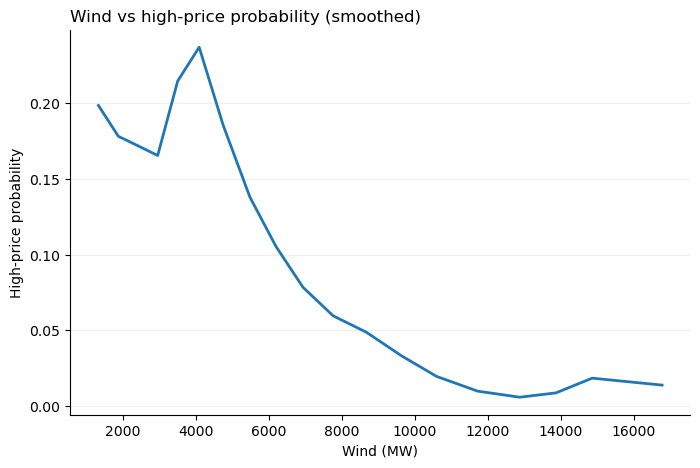

In [12]:
plt.figure(figsize=(8,5))

plt.plot(
    wind_curve['wind_mid'],
    wind_curve['prob_smooth'],
    linewidth=2
)

plt.xlabel("Wind (MW)")
plt.ylabel("High-price probability")
plt.title("Wind vs high-price probability (smoothed)", loc='left')

plt.grid(axis='y', alpha=0.2)
plt.gca().spines[['top','right']].set_visible(False)

plt.show()

The impact of wind on system stress is non-linear, with the largest 
reductions in high-price probability occurring as wind increases from 
low to moderate levels. Beyond ~11–12 GW, the marginal benefit of additional 
wind diminishes.

A univariate view of wind generation provides limited explanatory power 
for high-price events. The relationship becomes clearer when conditioning 
on system demand.

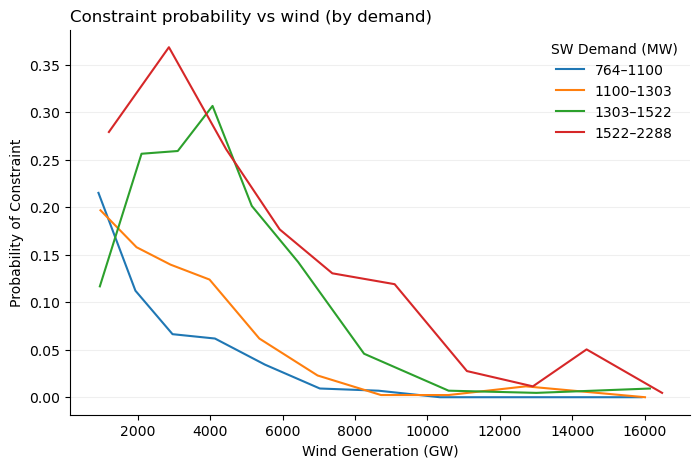

In [13]:
# =========================
# STRATIFIED WIND CURVES
# =========================

df['demand_bucket'] = pd.qcut(df['sw_demand_mw'], 4)

# Convert to readable labels
df['demand_bucket_label'] = df['demand_bucket'].apply(
    lambda x: f"{int(x.left)}–{int(x.right)}"
)

plt.figure(figsize=(8,5))

for label, group in df.groupby('demand_bucket_label', observed=True):
    
    temp = group.copy()
    temp['wind_bucket'] = pd.qcut(temp['wind_mw'], 10)
    
    curve = (
        temp.groupby('wind_bucket', observed=True)['constraint_event']
        .mean()
        .reset_index()
    )
    
    curve['wind_mid'] = curve['wind_bucket'].apply(lambda x: x.mid)
    
    curve = curve.sort_values('wind_mid')
    
    plt.plot(curve['wind_mid'], curve['constraint_event'], label=str(label))

# Style
plt.xlabel("Wind Generation (GW)")
plt.ylabel("Probability of Constraint")
plt.title("Constraint probability vs wind (by demand)", loc='left')

plt.legend(title = "SW Demand (MW)", frameon=False)
plt.grid(axis='y', alpha=0.2)
plt.gca().spines[['top','right']].set_visible(False)

plt.show()

The relationship between wind generation and system stress is conditional on demand.

While increasing wind generally reduces the probability of high-price events, 
the absolute level of risk is primarily determined by system demand. 

At high demand levels, stress probability remains elevated even at high wind, 
whereas at low demand levels, the system becomes resilient to stress at much lower wind output.

This highlights that wind acts as a mitigating factor, while demand sets the baseline risk.

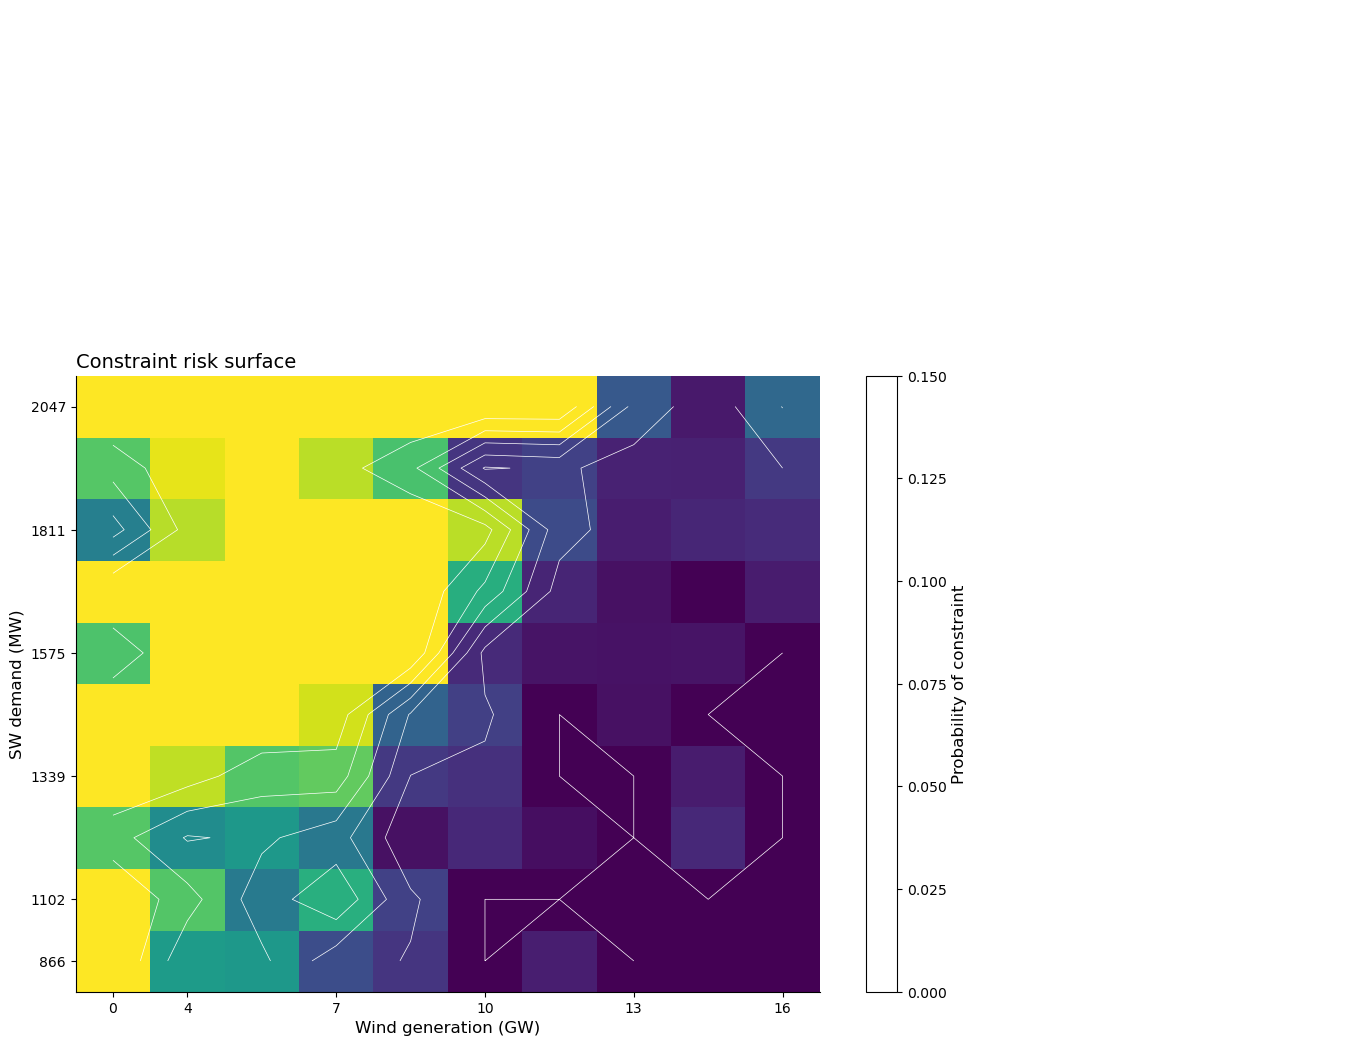

In [14]:
# =========================
# HEATMAP: CONSTRAINT RISK
# =========================

# Copy data
temp = df.copy()

# =========================
# BIN VARIABLES (FIRST)
# =========================

temp['wind_bin'] = pd.qcut(temp['wind_mw'], 10, duplicates='drop')
temp['demand_bin'] = pd.qcut(temp['sw_demand_mw'], 10, duplicates='drop')

# =========================
# BUILD HEATMAP
# =========================

heatmap = (
    temp.groupby(['demand_bin', 'wind_bin'], observed=True)['constraint_event']
    .mean()
    .unstack()
)

# =========================
# FILTER LOW-SAMPLE CELLS
# =========================

heatmap_counts = (
    temp.groupby(['demand_bin', 'wind_bin'], observed=True)
    .size()
    .unstack()
)

heatmap = heatmap.where(heatmap_counts > 50)

# =========================
# AXES
# =========================

wind_mid = heatmap.columns.map(lambda x: x.mid)
demand_mid = heatmap.index.map(lambda x: x.mid)

# =========================
# PLOT
# =========================

plt.figure(figsize=(12,8))

plt.imshow(
    heatmap.values,
    aspect='auto',
    origin='lower',
    vmin=0,
    vmax=0.15   # focus on meaningful range
)

heatmap = heatmap.clip(upper=0.15)

plt.contour(
    heatmap.values,
    levels=5,
    colors='white',
    linewidths=0.5
)

plt.xticks(
    ticks=np.linspace(0, len(wind_mid)-1, 6).astype(int),
    labels=[f"{int(w/1000)}" for w in np.linspace(wind_mid.min(), wind_mid.max(), 6)]
)

plt.yticks(
    ticks=np.linspace(0, len(demand_mid)-1, 6).astype(int),
    labels=[f"{int(d)}" for d in np.linspace(demand_mid.min(), demand_mid.max(), 6)]
)

plt.xlabel("Wind generation (GW)", fontsize=12)
plt.ylabel("SW demand (MW)", fontsize=12)
plt.title("Constraint risk surface", loc='left', fontsize=14)

cbar = plt.colorbar()
cbar.set_label("Probability of constraint", fontsize=12)

plt.grid(False)
plt.gca().spines[['top','right']].set_visible(False)

plt.text(2, 15, "Import-driven\nconstraints", color='white')
plt.text(15, 2, "Low-risk regime", color='white')

plt.show()

The risk surface shows that high-price events are concentrated
in high-demand, low-wind conditions.

This is consistent with increased reliance on higher-cost generation.

However, this reflects economic dispatch rather than network constraints,
and should not be interpreted as direct evidence of transmission limitations.

In [15]:
df['pred_prob'] = model_real.predict(X)

In [16]:
df['prob_bucket'] = pd.qcut(df['pred_prob'], 10)

In [17]:
calibration = (
    df.groupby('prob_bucket', observed=True)
    .agg(
        pred_mean=('pred_prob', 'mean'),
        actual_rate=('constraint_event', 'mean'),
        count=('constraint_event', 'size')
    )
    .reset_index()
)

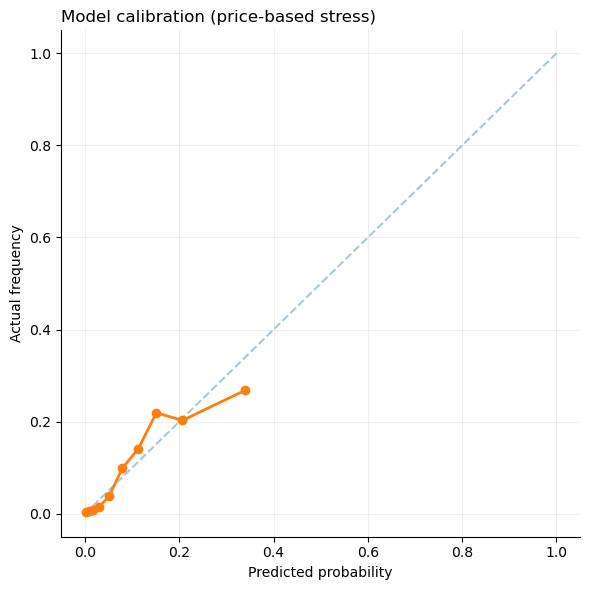

In [18]:
plt.figure(figsize=(6,6))

# Perfect calibration line
plt.plot([0,1], [0,1], linestyle='--', alpha=0.4)

# Model calibration
plt.plot(
    calibration['pred_mean'],
    calibration['actual_rate'],
    marker='o',
    linewidth=2
)

# Labels
plt.xlabel("Predicted probability")
plt.ylabel("Actual frequency")
plt.title("Model calibration (price-based stress)", loc='left')

# Minimal styling
plt.grid(alpha=0.2)
plt.gca().spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

The model is reasonably well calibrated at low to moderate probability levels,
but underestimates high-risk events.

This suggests that wind and demand capture baseline price dynamics,
but additional factors are required to explain extreme price spikes.

While price-based models provide useful insight into system stress,
they are influenced by market dynamics and do not isolate physical constraints.

The next notebook introduces a constraint signal derived directly from
Balancing Mechanism activity, providing a more direct measure of
transmission constraint behaviour.